# Benchmarking against MASIF ligand

MASIF ligand is set up as a multi-class classification problem.

* Which protein chain is the pocket? We can use all chains specified by the MASIF PDB chain ID's and just pair them with the ligand.
* PDB chain IDs with multiple distinct ligands. But the coordinates are distinct, so they should just be treated as separate examples.
* PDB chain IDs with multiple same ligands. We can deduplicate and just pick one example? 
* TODO: check on the class imbalance across the ligands.

In [21]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import biotite.structure as bs
import biotite.structure.io.pdb as pdb
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
import json

from atomica.data.converter import ligand_utils
from atomica.data import filter_for_segment

MASIF_LIGAND_LABELS = ["ADP", "COA", "FAD", "HEM", "NAD", "NAP", "SAM"]

MASIF_DATA_DIR = "/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/baselines/masif/data/masif_ligand/lists/"
MASIF_LIGAND_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00c-ligand_coords/"
PDB_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00b-pdbs_assembly/"
ATOMICA_DATA_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/"

sns.set_context("notebook")
baseline_color = '#B0B0B0'
atomica_color = '#00C4C7'
ensemble_color = '#059094'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Protein-Ligand structures to process

In [14]:
def get_chains_for_ligand(pdb_id: str, lig_code: str) -> list[str]:
    """
    Get the chains for a given ligand code.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    ligand = structure[:, structure.res_name == lig_code]
    ligand = list(zip(ligand.chain_id, ligand.res_id))
    return list(set(ligand))


def get_chains(pdb_id: str) -> list[str]:
    """
    Get the chains for a given PDB ID.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    structure = structure[:, bs.filter_canonical_amino_acids(structure)]
    chains = list(set(structure.chain_id))
    return chains

In [ ]:
to_process = []

with open(os.path.join(MASIF_DATA_DIR, "sequence_split_list.txt"), "r") as f:
    lines = f.readlines()
pdb_chain_ids = [line.strip() for line in lines]

for pdb_chain_id in tqdm(pdb_chain_ids, desc="Processing PDB chain IDs", total=len(pdb_chain_ids)):
    pdb_id = pdb_chain_id.split("_")[0]
    ligand_type = MASIF_LIGAND_DIR + f"{pdb_id}_ligand_types.npy"
    ligands = np.load(ligand_type)
    ligands = ligands.astype(str)
    for ligand in np.unique(ligands):
        lig_chains = get_chains_for_ligand(pdb_id, ligand)
        rec_chains = pdb_chain_id.split("_")[1]
        valid_chains = get_chains(pdb_id)
        rec_chains = [chain for chain in rec_chains if chain in valid_chains]
        for lig_chain, lig_resi in lig_chains:
            to_process.append({
                "pdb_id": pdb_id,
                "pdb_path": PDB_DIR + f"{pdb_id}.pdb",
                "chain1": "_".join(rec_chains),
                "chain2": lig_chain,
                "lig_code": ligand,
                "lig_resi": lig_resi,
            })

to_process_df = pd.DataFrame(to_process)
to_process_df['label'] = to_process_df['lig_code'].map(lambda x: MASIF_LIGAND_LABELS.index(x))
to_process_df['lig_smiles'] = to_process_df['lig_code'].apply(lambda x: ligand_utils.get_ligand_smiles(x))


Processing PDB chain IDs: 100%|██████████| 1468/1468 [03:02<00:00,  8.03it/s]


In [16]:
to_process_df['lig_code'].value_counts()

lig_code
ADP    757
HEM    473
FAD    446
COA    339
NAD    306
SAM    260
NAP    218
Name: count, dtype: int64

In [17]:
to_process_df.to_csv("masif_ligand_pdbs_to_process.csv", index=False)

Run `process_masif_ligand_pdbs.sh` to process the PDBs.

In [ ]:
to_process_df = pd.read_csv("masif_ligand_pdbs_to_process.csv")

In [ ]:
dpocket_input = to_process_df[['pdb_path', 'lig_code']].drop_duplicates()
dpocket_input.to_csv("dpocket/dpocket_input.tsv", sep="\t", index=False, header=False)

## Remove the ligand residues from the processed graphs

In [82]:
for dist_th in range(4,13):
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A.parquet")
    df = df.drop_duplicates(subset=['id']) # if there are multiple ligands on the same chain, drop the duplicates

    # Filter for only the pocket residues
    data_cols = ['X','B','A','atom_positions','block_lengths','segment_ids'] 
    filtered_data = df.apply(
        lambda row: filter_for_segment({k: row[k] for k in data_cols}, 0), axis=1
    )
    df[data_cols] = pd.json_normalize(filtered_data).to_numpy()
    df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only.parquet")

Compare pocket sizes, FAD is the largest pocket and ADP is the smallest.

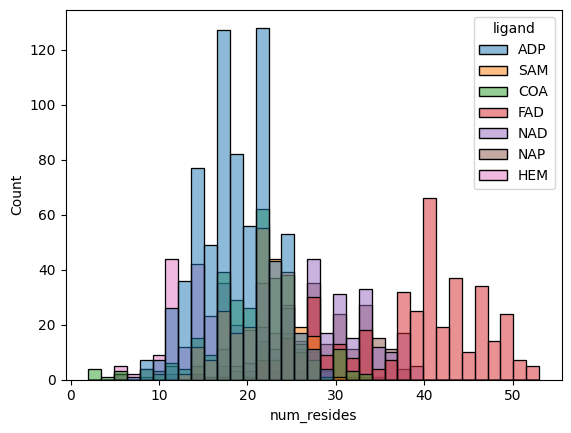

In [86]:
df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_6A_pocket_only.parquet")
pocket_size = pd.DataFrame({
    'num_resides': df['B'].apply(lambda x: len(x)), 
    'ligand': df['id'].str.split('_').str[-1]
})
pocket_size.groupby('ligand').agg(
    mean_num_resides=('num_resides', 'mean'),
    std_num_resides=('num_resides', 'std'),
)

sns.histplot(pocket_size, x='num_resides', hue='ligand')
plt.show()

## Prepare for dpocket

In [ ]:
for dist_th in range(4,13):
    dpocket_input = []
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A.parquet")
    for _, row in df.iterrows():
        dpocket_input.append(f"{row[]}")

In [6]:
df['id']

0         5EFQ_AB_A_ADP
1         4CRM_PX_P_ADP
2       3CR3_ACBD_B_ADP
3       3CR3_ACBD_A_ADP
4          3P4X_A_A_ADP
             ...       
2794      4NJJ_AB_B_SAM
2795      4NJJ_AB_A_SAM
2796      5C8T_AB_B_SAM
2797       2G72_A_A_SAM
2798       4FR0_A_A_SAM
Name: id, Length: 2509, dtype: object

## Train test splits

In [83]:
def _clean_pdb_chain_id(pdb_chain_id: str) -> str:
    pdb_id, chain_ids, *_ = pdb_chain_id.split('_')
    chain_ids = "".join(sorted(chain_ids))
    return pdb_id + "_" + chain_ids

train = np.load(os.path.join(MASIF_DATA_DIR, "train_pdbs_sequence.npy"))
train = train.astype(str)  # Convert byte strings to regular strings
train = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in train]

val = np.load(os.path.join(MASIF_DATA_DIR, "val_pdbs_sequence.npy"))
val = val.astype(str)  # Convert byte strings to regular strings
val = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in val]

test = np.load(os.path.join(MASIF_DATA_DIR, "test_pdbs_sequence.npy"))
test = test.astype(str)  # Convert byte strings to regular strings
test = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in test]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print(f"Train val overlap: {len(set(train) & set(val))}")
print(f"Test val overlap: {len(set(test) & set(val))}")

Train: 1036, Val: 115, Test: 287
Train val overlap: 0
Test val overlap: 0


In [84]:
def _assign_split(item_id: str) -> str:
    pdb_chain_id = _clean_pdb_chain_id(item_id)
    if pdb_chain_id in train:
        return 'train'
    elif pdb_chain_id in val:
        return 'val'
    elif pdb_chain_id in test:
        return 'test'

for dist_th in range(4,13):
    df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only.parquet")
    df['split'] = df['id'].apply(_assign_split)
    df.loc[df['id'] == '1FFT_ACB_A_HEM', 'split'] = 'train' # 1FFT_ABCD is in the train set of MASIF

    assert not df['split'].isna().any()

    # # Keep only the first ligand per PDB
    # # A lot of PDBs are symmetric, so we keep only the first ligand per PDB.
    # # Unclear how MASIF handle this, but this makes the dataset more comparable in size.
    # df['id_fixed'] = df['id'].apply(lambda x: "_".join(x.split('_')[:2] + x.split('_')[-1:]))
    # df = df.drop_duplicates('id_fixed')
    # df.drop(columns=['id_fixed'], inplace=True)

    for split in ['train', 'val', 'test']:
        split_df = df[df['split'] == split].copy()
        split_df.drop(columns=['split'], inplace=True)
        print(f"{split} {dist_th}A: {len(split_df)}, ligands: {split_df['id'].str.split('_').str[-1].value_counts().to_dict()}")
        split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")

train 4A: 1808, ligands: {'ADP': 526, 'FAD': 302, 'COA': 237, 'NAD': 206, 'HEM': 205, 'SAM': 187, 'NAP': 145}
val 4A: 199, ligands: {'ADP': 45, 'HEM': 29, 'NAD': 28, 'NAP': 27, 'COA': 26, 'FAD': 25, 'SAM': 19}
test 4A: 459, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 56, 'SAM': 50, 'NAD': 49, 'COA': 47, 'NAP': 28}
train 5A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'HEM': 229, 'NAD': 209, 'SAM': 187, 'NAP': 145}
val 5A: 203, ligands: {'ADP': 46, 'HEM': 30, 'COA': 28, 'NAD': 28, 'NAP': 27, 'FAD': 25, 'SAM': 19}
test 5A: 466, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 62, 'SAM': 50, 'NAD': 49, 'COA': 48, 'NAP': 28}
train 6A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'HEM': 229, 'NAD': 209, 'SAM': 187, 'NAP': 145}
val 6A: 203, ligands: {'ADP': 46, 'HEM': 30, 'COA': 28, 'NAD': 28, 'NAP': 27, 'FAD': 25, 'SAM': 19}
test 6A: 467, ligands: {'ADP': 150, 'FAD': 79, 'HEM': 62, 'SAM': 50, 'COA': 49, 'NAD': 49, 'NAP': 28}
train 7A: 1839, ligands: {'ADP': 528, 'FAD': 302, 'COA': 239, 'H

Unsure if training individually or merging is better for the different distance thresholds. So trying both.

Training individually and ensembling the results is best.

In [5]:
for split in ['train', 'val', 'test']:
    split_dfs = []
    for dist_th in range(8,13):
        split_df = pd.read_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_{dist_th}A_pocket_only_{split}.parquet")
        split_dfs.append(split_df)
    split_df = pd.concat(split_dfs)
    split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_8-12A_pocket_only_{split}.parquet")

## ATOMICA Ligand Predictions

In [2]:
# find the best checkpoints
from collections import defaultdict
checkpoints_list = []
for version in range(90, 0, -1):
    ckpt_dir = f"/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_{version}"
    if len(os.listdir(os.path.join(ckpt_dir, "checkpoint"))) == 0:
        continue
    with open(os.path.join(ckpt_dir, "args.json"), "r") as f:
        args = json.load(f)
    dist_th = os.path.basename(args['train_set']).replace("masif_ligand_pdbs_", "").replace("A_pocket_only_train.parquet", "")
    with open(os.path.join(ckpt_dir, "checkpoint", "topk_map.txt"), "r") as f:
        best_ckpt = f.readlines()[0].strip()
    auprc, ckpt_path = best_ckpt.split(": ")
    if float(auprc) < 1.0: 
        # some of the older models I used val loss, instead of auprc. So ignore them.
        version = os.path.dirname(os.path.dirname(ckpt_path)).split("_")[-1]
        epoch = os.path.basename(ckpt_path)
        checkpoints_list.append([int(dist_th), args['seed'], float(auprc), ckpt_path.replace(".ckpt", ".pt"), int(version), epoch])
checkpoints_df = pd.DataFrame(checkpoints_list, columns=["dist_th", "seed", "auprc", "ckpt_path", "version", "epoch"])
checkpoints_df = checkpoints_df.sort_values(by=['auprc'], ascending=False)
checkpoints_df = checkpoints_df.groupby(['dist_th'], as_index=False).head(3)
checkpoints_df = checkpoints_df.sort_values(by=['dist_th', 'version'])
checkpoints_df

,dist_th,seed,auprc,ckpt_path,version,epoch
39,5,2023,0.563867,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,51,epoch100_step3232.ckpt
25,5,2024,0.591872,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,65,epoch79_step2560.ckpt
22,5,2024,0.550973,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,68,epoch299_step9600.ckpt
21,6,2024,0.570588,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,69,epoch279_step12880.ckpt
19,6,2025,0.524777,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,71,epoch120_step5566.ckpt
13,6,2023,0.570345,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,77,epoch70_step3266.ckpt
27,7,2023,0.587920,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,63,epoch51_step3276.ckpt
20,7,2024,0.553301,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,70,epoch109_step6930.ckpt
10,7,2023,0.610232,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,80,epoch103_step6552.ckpt
41,8,2024,0.503068,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,49,epoch93_step7990.ckpt


In [27]:
# no lr decay here
# copy out of scratch

import shutil
import os

model_checkpoints={
    5: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_24/checkpoint/epoch92_step2976.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_25/checkpoint/epoch104_step3360.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_33/checkpoint/epoch127_step4096.pt",
    ],
    6: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_21/checkpoint/epoch147_step6808.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_27/checkpoint/epoch106_step4922.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_34/checkpoint/epoch98_step4554.pt",
    ],
    7: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_22/checkpoint/epoch55_step3528.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_28/checkpoint/epoch197_step12474.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_35/checkpoint/epoch183_step11592.pt",
    ],
    8: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_15/checkpoint/epoch59_step5100.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_29/checkpoint/epoch146_step12495.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_36/checkpoint/epoch68_step5865.pt",
    ],
    9: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_16/checkpoint/epoch47_step5280.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_26/checkpoint/epoch197_step21780.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_37/checkpoint/epoch199_step22200.pt",
    ],
    10: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_19/checkpoint/epoch48_step6664.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_31/checkpoint/epoch187_step25568.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_39/checkpoint/epoch193_step26384.pt",
    ],
    11: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_20/checkpoint/epoch34_step5740.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_30/checkpoint/epoch187_step30644.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_38/checkpoint/epoch81_step13366.pt"
    ],
    12: [
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_14/checkpoint/epoch64_step12545.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_32/checkpoint/epoch140_step27072.pt",
        "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_40/checkpoint/epoch151_step29032.pt",
    ],
}

dest_dir = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/atomica"

def model_checkpoint_to_new_path(ckpt_path: str, dist_th: int):
    version = os.path.basename(os.path.dirname(os.path.dirname(ckpt_path)))
    epoch = os.path.basename(ckpt_path)
    model_config = os.path.join(dest_dir, f"dist_{dist_th}", f"{version}_config.json")
    output_ckpt_path = os.path.join(dest_dir, f"dist_{dist_th}", f"{version}_{epoch}")
    return model_config, output_ckpt_path

# for dist_th, ckpt_paths in model_checkpoints.items():
#     for ckpt_path in ckpt_paths:
#         os.makedirs(os.path.join(dest_dir, f"dist_{dist_th}"), exist_ok=True)
#         version = os.path.basename(os.path.dirname(os.path.dirname(ckpt_path)))
#         epoch = os.path.basename(ckpt_path)
#         dest_path = os.path.join(dest_dir, f"dist_{dist_th}", f"{version}_{epoch}")

#         args_path = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), "args.json")
#         train_config = os.path.join(os.path.dirname(os.path.dirname(ckpt_path)), "train_config.json")
#         shutil.copy(args_path, os.path.join(dest_dir, f"dist_{dist_th}", f"{version}_args.json"))
#         shutil.copy(train_config, os.path.join(dest_dir, f"dist_{dist_th}", f"{version}_train_config.json"))

#         shutil.copy(ckpt_path, dest_path)
#         shutil.copy(ckpt_path.replace(".pt", ".ckpt"), dest_path.replace(".pt", ".ckpt"))
#         shutil.copy(os.path.join(os.path.dirname(ckpt_path), "config.json"), os.path.join(dest_dir, f"dist_{dist_th}", f"{version}_config.json"))

In [28]:
from atomica.models import MultiClassClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset
from torch.utils.data import DataLoader
from atomica.trainers import Trainer
import torch

def get_model(model_config: str, model_checkpoint: str) -> str:
    model = MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    return model

if not os.path.exists("atomica_results_df.parquet"):
    atomica_results = []
    for dist_th in range(5,13):
        dataset = MultiClassLabelledPDBDataset(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/masif_ligand_pdbs_{dist_th}A_pocket_only_test.parquet")
        for ckpt_path in model_checkpoints[dist_th]: # checkpoints_df[checkpoints_df['dist_th'] == dist_th].iterrows():
            config_path, ckpt_path = model_checkpoint_to_new_path(ckpt_path, dist_th)
            model = get_model(config_path, ckpt_path)
            atomica_preds = []
            model.eval()
            model.to("cuda")
            batch_size = 16
            for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc=f"Processing {dist_th}A"):
                with torch.no_grad():
                    batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
                    batch = MultiClassLabelledPDBDataset.collate_fn(batch)
                    batch = Trainer.to_device(batch, "cuda")
                    atomica_preds.append(model.infer(batch).cpu().numpy())
            atomica_preds = np.concatenate(atomica_preds)
            atomica_labels = np.array([x['label'] for x in dataset.data])
            pred_indxes = np.argmax(atomica_preds, axis=1)
            df = pd.DataFrame({
                'dist_th': dist_th,
                'id': [x['id'] for x in dataset.data],
                'label': atomica_labels,
                'pred': pred_indxes,
                'pred_probability': [atomica_preds[i] for i in range(len(atomica_preds))],
                'ckpt_path': ckpt_path,
            })
            atomica_results.append(df)
    atomica_results_df = pd.concat(atomica_results)
    atomica_results_df.to_parquet("atomica_results_df.parquet")

atomica_results_df = pd.read_parquet("atomica_results_df.parquet")

In [2]:
atomica_results_df = pd.read_parquet("atomica_results_df.parquet")

In [3]:
atomica_grouped_results_df = atomica_results_df[atomica_results_df['dist_th'].isin(range(5,13))].groupby('id').agg(
    label=('label', 'first'),
    pred=('pred', list),
    pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
    pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
    pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
    dist_th=('dist_th', list),
).reset_index()

atomica_grouped_results_df['pred_mode_accuracy'] = atomica_grouped_results_df['pred_mode'] == atomica_grouped_results_df['label']
atomica_grouped_results_df['pred_mode_probability_accuracy'] = atomica_grouped_results_df['pred_mode_probability'] == atomica_grouped_results_df['label']

In [4]:
# no ensemble accuracy
for dist_th in range(5,13):
    df = atomica_results_df[atomica_results_df['dist_th'] == dist_th].groupby('id').agg(
        label=('label', 'first'),
        pred=('pred', list),
        pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
        pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
        pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
        dist_th=('dist_th', list),
    ).reset_index()
    accuracy = np.sum(df['pred_mode'] == df['label']) / len(df)
    accuracy_probability = np.sum(df['pred_mode_probability'] == df['label']) / len(df)
    print(f"ATOMICA Accuracy {dist_th}A: {accuracy:.4f}, {accuracy_probability:.4f}")

ATOMICA Accuracy 5A: 0.7554, 0.7639
ATOMICA Accuracy 6A: 0.7580, 0.7859
ATOMICA Accuracy 7A: 0.7516, 0.7816
ATOMICA Accuracy 8A: 0.7516, 0.8009
ATOMICA Accuracy 9A: 0.7238, 0.7580
ATOMICA Accuracy 10A: 0.7602, 0.7816
ATOMICA Accuracy 11A: 0.7259, 0.7473
ATOMICA Accuracy 12A: 0.6424, 0.6959


5-13 with 3 seeds each, accuracy is now 0.8480 when you average the probabilities.

In [5]:
accuracy = atomica_grouped_results_df['pred_mode_accuracy'].mean()
print(f"ATOMICA ensemble vote accuracy: {accuracy:.4f}")

accuracy = atomica_grouped_results_df['pred_mode_probability_accuracy'].mean()
print(f"ATOMICA ensemble probability accuracy: {accuracy:.4f}")

ATOMICA ensemble vote accuracy: 0.8308
ATOMICA ensemble probability accuracy: 0.8480


## MASIF predictions

In [6]:
MASIF_PREDICTIONS_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/test_set_predictions"

In [7]:
masif_results = []
for pred_fname in glob(f"{MASIF_PREDICTIONS_DIR}/*_logits.npy"):
    item_id = os.path.basename(pred_fname).replace("_logits.npy", "")
    labels = np.load(os.path.join(MASIF_PREDICTIONS_DIR, f"{item_id}_labels.npy"))
    preds = np.load(pred_fname)
    if preds.shape == (0, ):
        print(f"No predictions for {item_id}")
        continue
    elif preds.shape[1:] != (100, 1, 1, 7):
        print(f"Invalid shape for {item_id}: {preds.shape}")
        continue
    preds = preds.mean(axis=1).squeeze()
    if preds.ndim == 1:
        preds = preds[None, :]
    for label, pred in zip(labels, preds):
        masif_results.append({
            'receptor_id': item_id,
            'label': label,
            'ligand': MASIF_LIGAND_LABELS[label],
            'pred': pred.argmax(axis=0),
            'pred_probability': pred,
        })
masif_results_df = pd.DataFrame(masif_results)
masif_results_df['pred_accuracy'] = masif_results_df['label'] == masif_results_df['pred']

No predictions for 3D36_ACB
No predictions for 2REQ_AB
No predictions for 1X7P_AB
No predictions for 2OWM_AC
No predictions for 3UQD_ACBD
No predictions for 1XX6_AB
No predictions for 4ZNL_A
No predictions for 4H6Q_A
No predictions for 5HMN_CE
No predictions for 4BLV_A
No predictions for 5L8J_AB


In [8]:
accuracy = masif_results_df['pred_accuracy'].mean()
print(f"MASIF Accuracy: {accuracy:.4f}")

MASIF Accuracy: 0.7871


### Merge the two results, since they don't have the exact same IDs
Also group the results by unique receptor and ligand pairs, as some receptors have multiple identical ligands.

In [9]:
atomica_grouped_results_df['receptor_id'] = atomica_grouped_results_df['id'].str.split('_').str[:2].str.join('_')
atomica_grouped_results_df['ligand'] = atomica_grouped_results_df['id'].str.split('_').str[-1]
atomica_grouped_results_df['masif_id'] = atomica_grouped_results_df['receptor_id'] + '_' + atomica_grouped_results_df['ligand']
masif_results_df['masif_id'] = masif_results_df['receptor_id'] + '_' + masif_results_df['ligand']

In [10]:
match_masif = atomica_grouped_results_df['masif_id'].isin(masif_results_df['masif_id'])
atomica_grouped_results_match_masif_df = atomica_grouped_results_df[match_masif].groupby('masif_id').agg(
    pred_mode_accuracy=('pred_mode_accuracy', 'mean'),
    pred_mode_probability_accuracy=('pred_mode_probability_accuracy', 'mean'),
)
atomica_grouped_results_match_masif_df.mean()

pred_mode_accuracy                0.850198
pred_mode_probability_accuracy    0.863095
dtype: float64

In [11]:
masif_results_df.groupby('masif_id').agg(
    accuracy=('pred_accuracy', 'mean'),
).mean()

accuracy    0.80754
dtype: float64

### ESM2 MLP predictions

Could try ensembling ESM2 with ATOMICA and see if it improves performance.

In [12]:
esm2_results = []

ESM2_MODEL_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/esm2"
for dist_th in range(5, 13):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/esm2_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_esm2.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM2_MODEL_DIR}/esm2_mlp_dist{dist_th}_finaldim32/seed{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm2_preds = json.load(f)
        if isinstance(esm2_preds, list):
            print(f"Error: ESM2 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm2_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm2_results.append(results)
esm2_results_df = pd.concat(esm2_results)
esm2_results_df_agg = esm2_results_df.groupby('id').agg(
    pred_probability=('pred_probability', lambda x: list(x)),
    label=('label', 'first'),
)

esm2_results_df_agg['pred_probability'] = esm2_results_df_agg['pred_probability'].apply(lambda x: np.array(x).mean(axis=0))
esm2_results_df_agg['pred'] = esm2_results_df_agg['pred_probability'].apply(lambda x: np.argmax(x))
esm2_results_df_agg['pred_accuracy'] = esm2_results_df_agg['pred'] == esm2_results_df_agg['label']
esm2_results_df_agg['pred_accuracy'].mean()

0.8865096359743041

In [13]:
esm3_results = []

ESM3_MODEL_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/esm3"
for dist_th in range(5, 13):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/esm3_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_esm3.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM3_MODEL_DIR}/esm3_mlp_dist{dist_th}_finaldim32/seed{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm3_preds = json.load(f)
        if isinstance(esm3_preds, list):
            print(f"Error: esm3 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm3_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm3_results.append(results)
esm3_results_df = pd.concat(esm3_results)
esm3_results_df_agg = esm3_results_df.groupby('id').agg(
    pred_probability=('pred_probability', lambda x: list(x)),
    label=('label', 'first'),
)

esm3_results_df_agg['pred_probability'] = esm3_results_df_agg['pred_probability'].apply(lambda x: np.array(x).mean(axis=0))
esm3_results_df_agg['pred'] = esm3_results_df_agg['pred_probability'].apply(lambda x: np.argmax(x))
esm3_results_df_agg['pred_accuracy'] = esm3_results_df_agg['pred'] == esm3_results_df_agg['label']
esm3_results_df_agg['pred_accuracy'].mean()

0.8779443254817987

## Joint models

In [14]:
esm2_results = []

ESM2_MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/atomica_esm2"
for dist_th in range(5, 13):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/atomica_esm2_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_atomica_esm2_seed{seed}.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM2_MODEL_DIR}/atomica_esm2_mlp_dist{dist_th}_finaldim32_no_layernorm_no_l2/{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm2_preds = json.load(f)
        if isinstance(esm2_preds, list):
            print(f"Error: ESM2 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm2_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm2_results.append(results)
atomica_esm2_results_df = pd.concat(esm2_results)
atomica_esm2_results_df_agg = atomica_esm2_results_df.groupby('id').agg(
    pred_probability=('pred_probability', lambda x: list(x)),
    label=('label', 'first'),
)

atomica_esm2_results_df_agg['pred_probability'] = atomica_esm2_results_df_agg['pred_probability'].apply(lambda x: np.array(x).mean(axis=0))
atomica_esm2_results_df_agg['pred'] = atomica_esm2_results_df_agg['pred_probability'].apply(lambda x: np.argmax(x))
atomica_esm2_results_df_agg['pred_accuracy'] = atomica_esm2_results_df_agg['pred'] == atomica_esm2_results_df_agg['label']
atomica_esm2_results_df_agg['pred_accuracy'].mean()

0.8950749464668094

In [15]:
esm3_results = []

ESM3_MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/atomica_esm3"
for dist_th in range(5, 13):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/atomica_esm3_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_atomica_esm3_seed{seed}.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM3_MODEL_DIR}/atomica_esm3_mlp_dist{dist_th}_finaldim32_no_layernorm_no_l2/{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm3_preds = json.load(f)
        if isinstance(esm3_preds, list):
            print(f"Error: ESM3 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm3_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm3_results.append(results)
atomica_esm3_results_df = pd.concat(esm3_results)
atomica_esm3_results_df_agg = atomica_esm3_results_df.groupby('id').agg(
    pred_probability=('pred_probability', lambda x: list(x)),
    label=('label', 'first'),
)

atomica_esm3_results_df_agg['pred_probability'] = atomica_esm3_results_df_agg['pred_probability'].apply(lambda x: np.array(x).mean(axis=0))
atomica_esm3_results_df_agg['pred'] = atomica_esm3_results_df_agg['pred_probability'].apply(lambda x: np.argmax(x))
atomica_esm3_results_df_agg['pred_accuracy'] = atomica_esm3_results_df_agg['pred'] == atomica_esm3_results_df_agg['label']
atomica_esm3_results_df_agg['pred_accuracy'].mean()

0.8715203426124197

## Dpocket

In [16]:
dpocket = pd.read_parquet('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/dpocket/dpocket_mlp_predictions.parquet')
dpocket = dpocket[dpocket['split'] == 'test']
dpocket['label'] = dpocket['true_label'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))
print("DPocket accuracy:", (dpocket['pred_label'] == dpocket['true_label']).mean())
dpocket

DPocket accuracy: 0.7577854671280276


,id,pred_probability,pred_label,true_label,split,label
1,4CRM_ADP,"[0.9285313, 0.007209783, 0.0061972165, 0.01575...",ADP,ADP,test,0
4,3KB1_ADP,"[0.55881494, 0.019398808, 0.0138840405, 0.0117...",ADP,ADP,test,0
16,4HLU_ADP,"[0.9686563, 0.01146111, 0.0061529833, 0.000830...",ADP,ADP,test,0
25,1NY5_ADP,"[0.88785034, 0.11167337, 0.00013036012, 6.0716...",ADP,ADP,test,0
28,5C3C_ADP,"[0.9782016, 0.017390266, 4.5706114e-05, 0.0001...",ADP,ADP,test,0
...,...,...,...,...,...,...
1434,3GYQ_SAM,"[0.82376176, 0.06098458, 0.014024705, 0.003739...",ADP,SAM,test,6
1437,4M7T_SAM,"[0.11626598, 0.008482881, 0.015345744, 0.03291...",SAM,SAM,test,6
1438,1JG4_SAM,"[0.37657812, 0.01436016, 0.20754841, 0.0082366...",ADP,SAM,test,6
1441,4NJJ_SAM,"[0.8522668, 0.013908534, 0.010071485, 0.026488...",ADP,SAM,test,6


## Conclusion
MASIF and ATOMICA perform comparably. For further improvements of ATOMICA:
* ensembling different patch sizes was very useful, let's see how far we can push this.
* MASIF and ATOMICA are using different signals, so it might be useful to include some of the phsicochemical features from MASIF in the ATOMICA model.

Other baselines
* ESM 2 and ESM 3 embeddings of the pocket residues?
* Fold seek embeddings?

In [17]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

def calculate_per_class_metrics(
    y_true,
    y_pred_proba,
    class_names=None,
    f1_mode="argmax",         # "argmax" | "fixed" | "optimal"
    fixed_threshold=0.5
):
    """
    Calculate per-class AUROC, AUPRC, and F1 for multiclass classification.

    Args:
        y_true: array-like of shape (n_samples,), int labels in [0, n_classes-1]
        y_pred_proba: array of shape (n_samples, n_classes), class probabilities
        class_names: optional list of names of length n_classes
        f1_mode:
            - "argmax": derive hard labels via argmax over classes
            - "fixed": per-class one-vs-rest thresholding at `fixed_threshold`
            - "optimal": per-class threshold chosen to maximize F1 on PR curve
        fixed_threshold: threshold used when f1_mode="fixed"
    Returns:
        dict with per-class metrics and macro averages
    """
    y_true = np.asarray(y_true)
    n_classes = y_pred_proba.shape[1]
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    # One-vs-rest binarized ground truth
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    results = {}
    thresholds_used = {}

    # If using argmax, compute hard predictions once
    if f1_mode == "argmax":
        y_pred_hard = y_pred_proba.argmax(axis=1)

    for i in range(n_classes):
        cls = class_names[i]

        # skip classes absent in y_true
        if y_true_bin[:, i].sum() == 0:
            results[f"{cls}_AUROC"] = np.nan
            results[f"{cls}_AUPRC"] = np.nan
            results[f"{cls}_F1"] = np.nan
            thresholds_used[cls] = np.nan
            continue

        # AUROC (OvR)
        try:
            results[f"{cls}_AUROC"] = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
        except ValueError:
            results[f"{cls}_AUROC"] = np.nan

        # AUPRC (OvR)
        try:
            precision, recall, pr_thresholds = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
            results[f"{cls}_AUPRC"] = auc(recall, precision)
        except ValueError:
            precision = recall = pr_thresholds = None
            results[f"{cls}_AUPRC"] = np.nan

        # F1 (choose strategy)
        if f1_mode == "argmax":
            # Standard multiclass F1 computed from hard labels
            f1s = f1_score(y_true, y_pred_hard, average=None, labels=np.arange(n_classes))
            results[f"{cls}_F1"] = f1s[i]
            thresholds_used[cls] = "argmax"
        elif f1_mode == "fixed":
            y_pred_bin_i = (y_pred_proba[:, i] >= fixed_threshold).astype(int)
            results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
            thresholds_used[cls] = fixed_threshold
        elif f1_mode == "optimal":
            # pick threshold that maximizes F1 on PR curve
            if precision is None or recall is None or pr_thresholds is None:
                results[f"{cls}_F1"] = np.nan
                thresholds_used[cls] = np.nan
            else:
                # precision, recall length = len(thresholds)+1; align by dropping first point
                pr_thresholds_full = np.r_[[-np.inf], pr_thresholds]  # sentinel to align lengths
                f1_vals = 2 * precision * recall / (precision + recall + 1e-12)
                best_idx = np.nanargmax(f1_vals)
                best_thresh = pr_thresholds_full[best_idx]
                # For sentinel (−inf), fall back to min prob − eps to classify almost all as positive
                if np.isneginf(best_thresh):
                    best_thresh = y_pred_proba[:, i].min() - 1e-12
                y_pred_bin_i = (y_pred_proba[:, i] >= best_thresh).astype(int)
                results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
                thresholds_used[cls] = float(best_thresh)
        else:
            raise ValueError("f1_mode must be 'argmax', 'fixed', or 'optimal'.")

    # Macro averages (ignore NaNs)
    auroc_vals = [v for k, v in results.items() if k.endswith("_AUROC") and not np.isnan(v)]
    auprc_vals = [v for k, v in results.items() if k.endswith("_AUPRC") and not np.isnan(v)]
    f1_vals =   [v for k, v in results.items() if k.endswith("_F1")    and not np.isnan(v)]

    results["Macro_Avg_AUROC"] = np.mean(auroc_vals) if auroc_vals else np.nan
    results["Macro_Avg_AUPRC"] = np.mean(auprc_vals) if auprc_vals else np.nan
    results["Macro_Avg_F1"] = np.mean(f1_vals) if f1_vals else np.nan
    results["Micro_Avg_F1"] = f1_score(y_true, y_pred_hard, average='micro')
    results["_thresholds_used"] = thresholds_used  # optional: helpful for debugging

    return results

In [19]:
metrics_table = []

# atomica_esm3_metrics = calculate_per_class_metrics(atomica_esm3_results_df_agg['label'], np.stack(atomica_esm3_results_df_agg['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
# for metric, value in atomica_esm3_metrics.items():
#     metrics_table.append({
#         'Model': 'ATOMICA ESM3',
#         'Metric': metric,
#         'Value': value
#     })

dpocket_metrics = calculate_per_class_metrics(dpocket['label'], np.stack(dpocket['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in dpocket_metrics.items():
    metrics_table.append({
        'Model': 'DPocket',
        'Metric': metric,
        'Value': value
    })


masif_metrics = calculate_per_class_metrics(masif_results_df['label'], np.stack(masif_results_df['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in masif_metrics.items():
    metrics_table.append({
        'Model': 'MASIF',
        'Metric': metric,
        'Value': value
    })

esm2_mlp_metrics = calculate_per_class_metrics(esm2_results_df_agg['label'], np.stack(esm2_results_df_agg['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in esm2_mlp_metrics.items():
    metrics_table.append({
        'Model': 'ESM2',
        'Metric': metric,
        'Value': value
    })

esm3_mlp_metrics = calculate_per_class_metrics(esm3_results_df_agg['label'], np.stack(esm3_results_df_agg['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in esm3_mlp_metrics.items():
    metrics_table.append({
        'Model': 'ESM3',
        'Metric': metric,
        'Value': value
    })

atomica_metrics = calculate_per_class_metrics(atomica_grouped_results_df['label'], np.stack(atomica_grouped_results_df['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in atomica_metrics.items():
    metrics_table.append({
        'Model': 'ATOMICA',
        'Metric': metric,
        'Value': value
    })


atomica_esm2_metrics = calculate_per_class_metrics(atomica_esm2_results_df_agg['label'], np.stack(atomica_esm2_results_df_agg['pred_probability'].tolist()), MASIF_LIGAND_LABELS)
for metric, value in atomica_esm2_metrics.items():
    metrics_table.append({
        'Model': 'ATOMICA ESM2',
        'Metric': metric,
        'Value': value
    })


metrics_table_df = pd.DataFrame(metrics_table)
metrics_table_df.pivot(index='Metric', columns='Model', values='Value')

Model,ATOMICA,ATOMICA ESM2,DPocket,ESM2,ESM3,MASIF
Metric,,,,,,
ADP_AUPRC,0.958538,0.951482,0.892091,0.950615,0.958538,0.930552
ADP_AUROC,0.969064,0.956677,0.935341,0.954848,0.963449,0.928182
ADP_F1,0.899023,0.881029,0.81,0.881029,0.891026,0.855967
COA_AUPRC,0.854856,0.94983,0.647882,0.943958,0.887046,0.668321
COA_AUROC,0.970413,0.990138,0.929858,0.987257,0.976028,0.935629
COA_F1,0.738095,0.888889,0.56,0.863636,0.818182,0.650602
FAD_AUPRC,0.967428,0.98549,0.823643,0.982871,0.977105,0.773617
FAD_AUROC,0.989625,0.997162,0.971426,0.996835,0.99465,0.940329
FAD_F1,0.919255,0.95122,0.804124,0.95122,0.915663,0.766667


/tmp/ipykernel_942326/2070304711.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['Metric'].str.replace('_AUROC', ''))


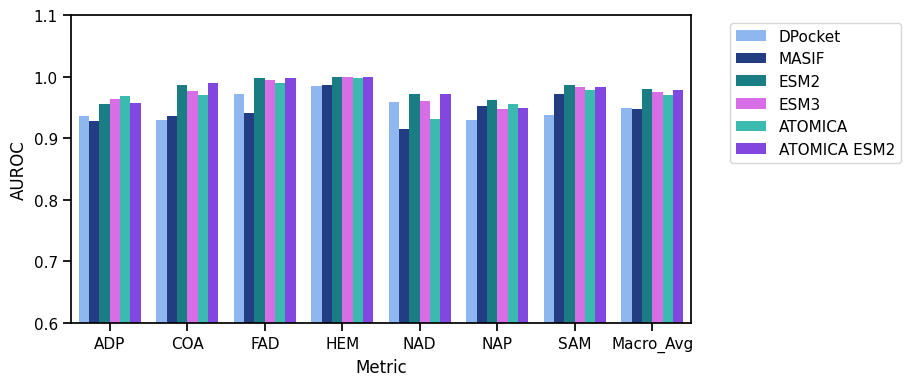

In [47]:
plot_df = metrics_table_df[metrics_table_df['Metric'].str.endswith('AUROC')]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model', ax=ax, palette=custom_colors[::-1])
ax.set_ylim(0.6, 1.1)
ax.set_xticklabels(plot_df['Metric'].str.replace('_AUROC', ''))
ax.set_ylabel('AUROC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

/tmp/ipykernel_942326/2926356336.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['Metric'].str.replace('_AUPRC', ''))


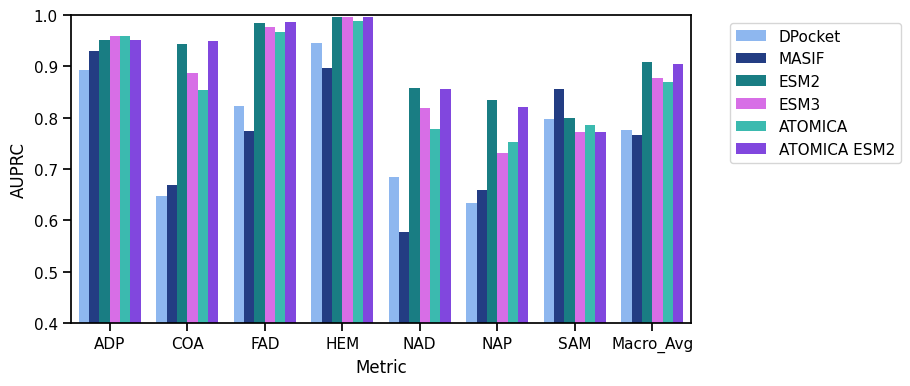

In [48]:
plot_df = metrics_table_df[metrics_table_df['Metric'].str.endswith('AUPRC')]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model', ax=ax, palette=custom_colors[::-1])
ax.set_ylim(0.4, 1.0)
ax.set_xticklabels(plot_df['Metric'].str.replace('_AUPRC', ''))
ax.set_ylabel('AUPRC')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

/tmp/ipykernel_1855859/377047055.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df['Metric'].str.replace('_F1', '').replace('Macro_Avg', 'Macro\nAverage').replace('Micro_Avg', 'Micro\nAverage'))


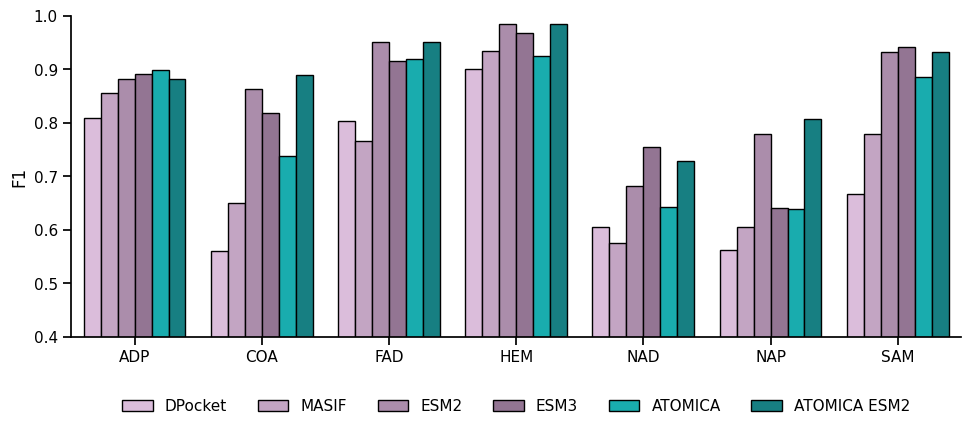

In [45]:
plot_df = metrics_table_df[metrics_table_df['Metric'].str.endswith('F1') & ~metrics_table_df['Metric'].str.contains('Avg')]
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=plot_df, x='Metric', y='Value', hue='Model', ax=ax,
    palette=[
        '#E0B8E0', '#C8A0C8', '#B088B0', '#987098', atomica_color, ensemble_color
    ])
sns.despine()
ax.set_ylim(0.4, 1.0)
ax.set_xticklabels(plot_df['Metric'].str.replace('_F1', '').replace('Macro_Avg', 'Macro\nAverage').replace('Micro_Avg', 'Micro\nAverage'))
ax.set_ylabel('F1')
ax.set_xlabel('')

# Add black outlines to all bars
for patch in ax.patches:
    patch.set_edgecolor('black')
    patch.set_linewidth(1)

plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=6, frameon=False)
plt.tight_layout()
plt.savefig('masif_ligand_benchmark_f1.svg', format='svg', bbox_inches='tight')
plt.show()

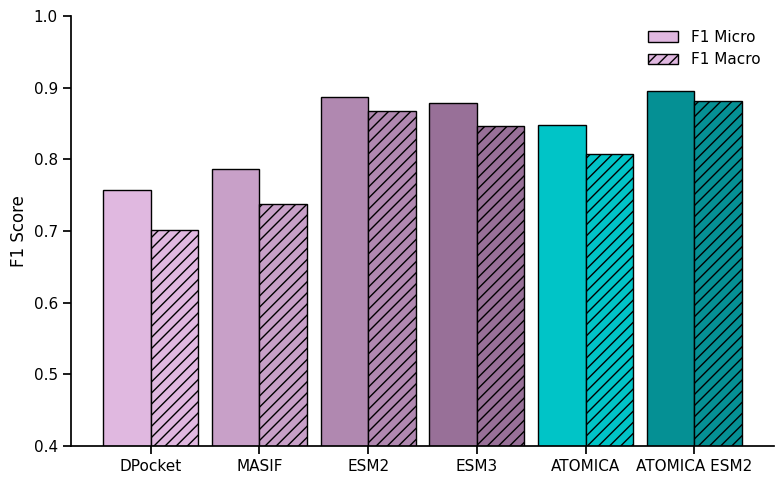

In [46]:
plot_df = metrics_table_df[metrics_table_df['Metric'].str.endswith('F1') & metrics_table_df['Metric'].str.contains('Avg')]

# Separate micro and macro
micro_df = plot_df[plot_df['Metric'].str.contains('Micro')].copy()
macro_df = plot_df[plot_df['Metric'].str.contains('Macro')].copy()

# Get unique models in order
models = plot_df['Model'].unique()
n_models = len(models)

# Prepare data for grouped bars
width = 0.35  # Width of each bar
spacing = 0.8  # Spacing between model groups

# Create x positions with gaps between model groups
x = np.arange(n_models) * spacing

# Get values for both metrics for each model
f1_micro_means = [micro_df[micro_df['Model'] == model]['Value'].values[0] if len(micro_df[micro_df['Model'] == model]) > 0 else 0 for model in models]
f1_macro_means = [macro_df[macro_df['Model'] == model]['Value'].values[0] if len(macro_df[macro_df['Model'] == model]) > 0 else 0 for model in models]

# Create the plot
fig, ax = plt.subplots(figsize=(8, 5))

# Define colors for models
model_colors = ['#E0B8E0', '#C8A0C8', '#B088B0', '#987098', atomica_color, ensemble_color]

# Plot bars side by side with no gap (adjacent positions)
# f1_micro bars (left, solid)
for i, model in enumerate(models):
    ax.bar(x[i] - width/2, f1_micro_means[i], width, 
           color=model_colors[i], edgecolor='black', linewidth=1, 
           label='F1 Micro' if i == 0 else '')

# f1_macro bars (right, with diagonal hatching)
for i, model in enumerate(models):
    ax.bar(x[i] + width/2, f1_macro_means[i], width, 
           color=model_colors[i], edgecolor='black', linewidth=1,
           hatch='///', label='F1 Macro' if i == 0 else '')

# Customize the plot
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('', fontsize=12)
ax.set_ylim(0.4, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='best', frameon=False)
sns.despine()

plt.tight_layout()
plt.savefig('masif_ligand_benchmark_f1_avg.svg', format='svg', bbox_inches='tight')
plt.show()